In [1]:
import math

In [2]:
# 1. Value nesnesi: önce sadece sayıyı saklayan en basit hâli.
class Value():

  def __init__(self,data):

    self.data = data

  def __repr__(self):
    return f"Value (data = {self.data})"

a = Value(2.0)
a

Value (data = 2.0)

In [3]:
class Value():

  def __init__(self,data, children = (),_op = '',label = ''):

    self.data = data
    self._prev = set(children)
    self._op = _op
    self.grad = 0.0
    self.label = label
    self._backward = lambda: None

  def __repr__(self):
    return f"Value (data = {self.data})"

  def __add__(self,other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self,other), "+")
    def _backward():
      self.grad += out.grad * 1.0
      other.grad += out.grad * 1.0
    out._backward = _backward
    return out
  def __pow__(self,other):
    assert isinstance(other, (int,float))
    out = Value(self.data**other,(self,), f'**{other}')
    def _backward():
      self.grad += (other * self.data**(other - 1) * out.grad)
    out._backward = _backward
    return out
  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self,other), "*")
    def _backward():
      self.grad += out.grad * other.data
      other.grad += out.grad * self.data
    out._backward = _backward
    return out
  def __rmul__(self,other):
    return self * other
  def __radd__(self,other):
    return self + other
  def __truediv__(self,other):
    return self * other ** -1
  def __neg__(self):
    return self * -1
  def __sub__(self,other):
    return self + (-other)
  def tanh(self):
    e = math.e
    x = self.data
    y = (e**(2*x) - 1) / (e**(2*x) + 1)
    output = Value(y, children=(self,), _op = 'tanh')
    def _backward():
      self.grad += output.grad * (1- y**2)
    output._backward =  _backward
    return output

  def exp(self):
     x = self.data
     out = Value(math.exp(x), (self,), 'exp')
     def _backward():
      self.grad += out.data * out.grad
     out._backward =  _backward
     return out
  # 3. Çıkıştan başlayıp düğümleri ters sırada geziyorum.
  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

a = Value(5.0, label = "a")
b = Value(6.0, label = "b")
c = Value(7.0, label = "c")
d = a * b
d.label = 'd'
e = c + d
e.label = 'e'
f = Value(-5.0, label = 'f')
L = e * f
L.label = "L"
L

Value (data = -185.0)

In [4]:
x = Value(3.0)
y = x**2
y.backward()
print(y.data,x.grad)

9.0 6.0


In [5]:
a = Value(2)
b = Value(4)
c = a / b
c.backward()
print(c.data,a.grad,b.grad)

0.5 0.25 -0.125


In [6]:
x = Value(2)
y = x.exp()
y.backward()
print(x.grad,y)

7.38905609893065 Value (data = 7.38905609893065)


In [7]:
print(a + 1)
print(2 * a)
print(a * 2)

Value (data = 3)
Value (data = 4)
Value (data = 4)


In [8]:
try:
  from graphviz import Digraph
except ModuleNotFoundError:
  Digraph = None

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  if Digraph is None:
    return None

  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

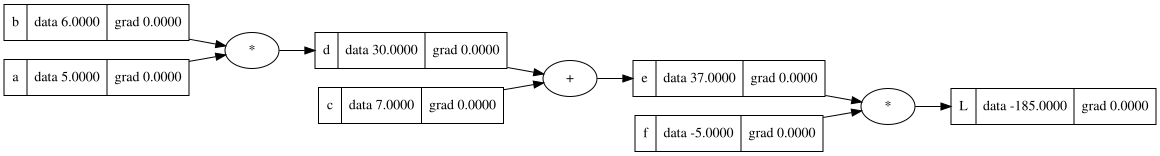

In [9]:
draw_dot(L)

## 2. Önce elle gradient hesaplama

`backward()` yazmadan önce küçük grafikte zincir kuralını elle uyguluyorum. Böylece her sayının nereden geldiği daha görünür oluyor.

In [10]:
def numerical_derivative_a():

  h = 0.0001

  a = Value(5.0, label = "a")
  b = Value(6.0, label = "b")
  c = Value(7.0, label = "c")
  d = a * b
  d.label = 'd'
  e = c + d
  e.label = 'e'
  f = Value(-5.0, label = 'f')
  L = e * f
  L.label = "L"
  L1 = L.data

  a = Value(5.0, label = "a")
  a.data += h
  b = Value(6.0, label = "b")
  c = Value(7.0, label = "c")
  d = a * b
  d.label = 'd'
  e = c + d
  e.label = 'e'
  f = Value(-5.0, label = 'f')
  L = e * f
  L.label = "L"
  L2 = L.data

  print('Sayısal türev (dL/da):', (L2 - L1) / h)

numerical_derivative_a()

Sayısal türev (dL/da): -29.99999999985903


∂L/∂c = ∂L/∂e × ∂e/∂c
∂L/∂d = ∂L/∂e × ∂e/∂d

In [11]:
# Bu örneği burada tekrar kuruyorum. Böylece aşağıdaki denemelerde
# a, b ve c isimleri yeniden kullanılsa bile bu grafiğin değerleri karışmıyor.
a_simple = Value(5.0, label='a')
b_simple = Value(6.0, label='b')
c_simple = Value(7.0, label='c')
f_simple = Value(-5.0, label='f')
d_simple = a_simple * b_simple
e_simple = c_simple + d_simple
L_simple = e_simple * f_simple

L_simple.grad = 1.0
e_simple.grad = f_simple.data * L_simple.grad
f_simple.grad = e_simple.data * L_simple.grad

∂e/∂c = 1
∂e/∂d = 1

In [12]:
c_simple.grad = e_simple.grad * 1.0
d_simple.grad = e_simple.grad * 1.0

In [13]:
a_simple.grad = d_simple.grad * b_simple.data
b_simple.grad = d_simple.grad * a_simple.data

print('a.grad:', a_simple.grad)
print('b.grad:', b_simple.grad)
print('c.grad:', c_simple.grad)
print('f.grad:', f_simple.grad)

a.grad: -30.0
b.grad: -25.0
c.grad: -5.0
f.grad: 37.0


In [14]:
w1 = Value(2.0,label = "weight 1")
w2 = Value(0.8,label = "weight 2")
x1 = Value(-3.0,label = "input 1")
x2 = Value(1.0, label="input 2")
b = Value(6.8813735870195432, label = "bias")


w1x1 = w1 * x1
w1x1.label = 'w1*x1'

w2x2 = w2 * x2
w2x2.label = 'w2*x2'
result = w1x1 + w2x2
result.label = "result"
n = result + b
n.label = "n"
o = n.tanh()  # tanh, Value sınıfının bir metodu olduğu için n üzerinden çağrılıyor.
o.label = 'output'


In [15]:
# Bu hücrede gradyanları bilerek elle yazıyorum.
o.grad = 1.0
n.grad = o.grad * (1 - o.data**2)
result.grad = n.grad * 1.0
b.grad = n.grad * 1.0
w1x1.grad = result.grad * 1.0
w2x2.grad = result.grad * 1.0
w1.grad = w1x1.grad * x1.data
x1.grad = w1x1.grad * w1.data
w2.grad = w2x2.grad * x2.data
x2.grad = w2x2.grad * w2.data

print('output:', o.data)
print('w1, x1, w2, x2, b:', w1.grad, x1.grad, w2.grad, x2.grad, b.grad)

output: 0.9330395746710234
w1, x1, w2, x2, b: -0.38831145629314734 0.25887430419543156 0.12943715209771578 0.10354972167817263 0.12943715209771578


In [16]:
# Aynı değişken iki kez kullanılırsa grad değerleri toplanmalı.
a = Value(3.0, label='a')
w3 = a + a
w3.label = 'a + a'
w3.backward()
print('a.grad =', a.grad)  # 2.0 olmalı


a.grad = 2.0


In [17]:
# Aynı neuron'u bu kez otomatik backward() ile çalıştırıyorum.
w1 = Value(2.0, label='weight 1')
w2 = Value(0.8, label='weight 2')
x1 = Value(-3.0, label='input 1')
x2 = Value(1.0, label='input 2')
b = Value(6.8813735870195432, label='bias')

w1x1 = w1 * x1
w1x1.label = 'w1*x1'
w2x2 = w2 * x2
w2x2.label = 'w2*x2'
result = w1x1 + w2x2
result.label = 'result'
n = result + b
n.label = 'n'
o = n.tanh()
o.label = 'output'

o.backward()
direct_output = o.data
direct_grads = {
    'w1': w1.grad, 'x1': x1.grad, 'w2': w2.grad,
    'x2': x2.grad, 'b': b.grad,
}

print('output:', direct_output)
print('w1, x1, w2, x2, b:', w1.grad, x1.grad, w2.grad, x2.grad, b.grad)

output: 0.9330395746710234
w1, x1, w2, x2, b: -0.38831145629314734 0.25887430419543156 0.12943715209771578 0.10354972167817263 0.12943715209771578


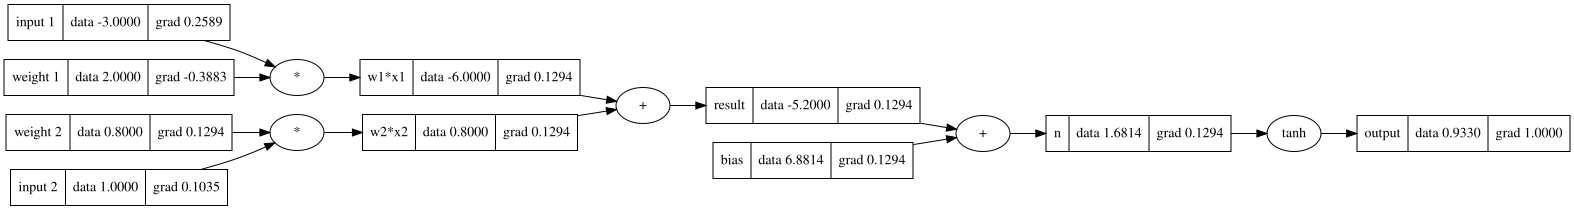

In [18]:
draw_dot(o)

In [19]:
w1 = Value(2.0, label='weight 1')
w2 = Value(0.8, label='weight 2')
x1 = Value(-3.0, label='input 1')
x2 = Value(1.0, label='input 2')
b = Value(6.8813735870195432, label='bias')

w1x1 = w1 * x1
w1x1.label = 'w1*x1'

w2x2 = w2 * x2
w2x2.label = 'w2*x2'

result = w1x1 + w2x2
result.label = 'result'

n = result + b
n.label = 'n'

# tanh(x) = (e^(2x) - 1) / (e^(2x) + 1)
e2n = (2 * n).exp()
e2n.label = 'e2n'
o = (e2n - 1) / (e2n + 1)
o.label = 'output'
print('output:', o.data)

output: 0.9330395746710234


Parçalanmış tanh output: 0.9330395746710234
Parçalanmış tanh gradyanları: {'w1': -0.38831145629314723, 'x1': 0.2588743041954315, 'w2': 0.12943715209771575, 'x2': 0.10354972167817261, 'b': 0.12943715209771575}
Normal ve parçalanmış tanh karşılaştırması:
w1 | normal: -0.38831145629314734 | parçalanmış: -0.38831145629314723
x1 | normal: 0.25887430419543156 | parçalanmış: 0.2588743041954315
w2 | normal: 0.12943715209771578 | parçalanmış: 0.12943715209771575
x2 | normal: 0.10354972167817263 | parçalanmış: 0.10354972167817261
b | normal: 0.12943715209771578 | parçalanmış: 0.12943715209771575


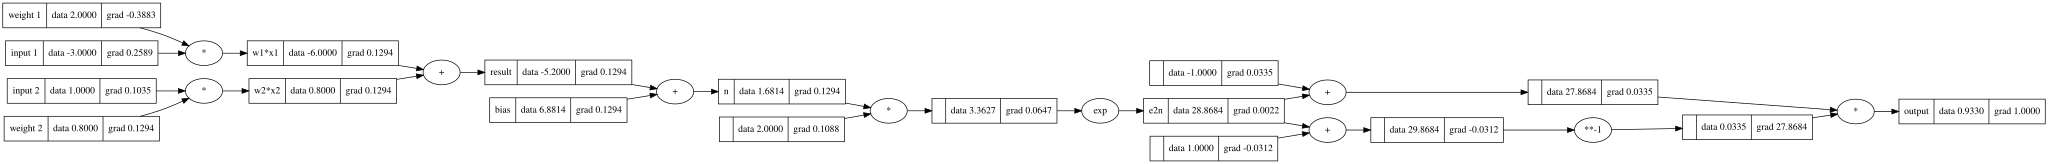

In [20]:
o.backward()
backward_grads = {
    'w1': w1.grad, 'x1': x1.grad, 'w2': w2.grad,
    'x2': x2.grad, 'b': b.grad,
}
print('Parçalanmış tanh output:', o.data)
print('Parçalanmış tanh gradyanları:', backward_grads)
print('Normal ve parçalanmış tanh karşılaştırması:')
for name in direct_grads:
    print(name, '| normal:', direct_grads[name], '| parçalanmış:', backward_grads[name])

draw_dot(o)


### PyTorch ile kontrol

Aynı işlemi şimdi PyTorch'a yaptırıyorum. `requires_grad=True`, o değişkenin türevini takip etmesini açıyor. `float64` kullanmamın sebebi de küçük farkları daha net görmek.

Sonuç ve `.grad` değerleri kendi `Value` sınıfımdan çıkan değerlerle aynı olmalı.

In [21]:
try:
    import torch
except ModuleNotFoundError:
    torch = None
    print('PyTorch yüklü değil; bu kontrolü Colab veya PyTorch yüklü ortamda çalıştırmalıyım.')

if torch is not None:
    x1 = torch.tensor([-3.0], dtype=torch.float64, requires_grad=True)
    x2 = torch.tensor([1.0], dtype=torch.float64, requires_grad=True)
    w1 = torch.tensor([2.0], dtype=torch.float64, requires_grad=True)
    w2 = torch.tensor([0.8], dtype=torch.float64, requires_grad=True)
    b = torch.tensor([6.8813735870195432], dtype=torch.float64, requires_grad=True)

    n = x1 * w1 + x2 * w2 + b
    o = torch.tanh(n)
    o.backward()

    print('output:', o.item())
    print('w1, x1, w2, x2, b:', w1.grad.item(), x1.grad.item(), w2.grad.item(), x2.grad.item(), b.grad.item())


output: 0.9330395746710234
w1, x1, w2, x2, b: -0.38831145629314734 0.25887430419543156 0.12943715209771578 0.10354972167817263 0.12943715209771578


In [22]:
# Sayısal türev kontrolünü aşağıda, forward_pass tanımlandıktan sonra yapıyorum.

### Sayısal türev ile kontrol

Burada `Value` kullanmıyorum. Bir parametreyi çok küçük miktarda değiştirip output farkına bakıyorum. Bu yaklaşık türev, `backward()` sonucuna yakın çıkmalı.

In [23]:
def forward_pass(w1,x1,w2,x2,b):

  n = (w1 * x1) + (w2 * x2) + b
  e2n = math.exp(2*n)
  output = (e2n - 1) / (e2n + 1)
  return output
w1 = 2.0
w2 = 0.8
x1 = -3.0
x2 = 1.0
b = 6.8813735870195432

print(forward_pass(w1, x1, w2, x2, b))

0.9330395746710234


In [24]:
h = 0.000001

v1 = forward_pass(w1, x1, w2, x2, b)

w1_grad = (forward_pass(w1 + h, x1, w2, x2, b) - v1) / h
x1_grad = (forward_pass(w1, x1 + h, w2, x2, b) - v1) / h
w2_grad = (forward_pass(w1, x1, w2 + h, x2, b) - v1) / h
x2_grad = (forward_pass(w1, x1, w2, x2 + h, b) - v1) / h
b_grad = (forward_pass(w1, x1, w2, x2, b + h) - v1) / h

print(w1_grad)
print(x1_grad)
print(w2_grad)
print(x2_grad)
numerical_grads = {
    'w1': w1_grad, 'x1': x1_grad, 'w2': w2_grad,
    'x2': x2_grad, 'b': b_grad,
}
print(numerical_grads)

-0.38831254334237286
0.2588738211573016
0.12943703131540474
0.10354964441461334
{'w1': -0.38831254334237286, 'x1': 0.2588738211573016, 'w2': 0.12943703131540474, 'x2': 0.10354964441461334, 'b': 0.12943703131540474}


In [25]:
if torch is not None:
    w1_t = torch.tensor([2.0], dtype=torch.float64, requires_grad=True)
    w2_t = torch.tensor([0.8], dtype=torch.float64, requires_grad=True)
    x1_t = torch.tensor([-3.0], dtype=torch.float64, requires_grad=True)
    x2_t = torch.tensor([1.0], dtype=torch.float64, requires_grad=True)
    b_t = torch.tensor([6.8813735870195432], dtype=torch.float64, requires_grad=True)

    n_t = w1_t * x1_t + w2_t * x2_t + b_t
    e2n_t = torch.exp(2 * n_t)
    o_t = (e2n_t - 1) / (e2n_t + 1)
    o_t.backward()

    torch_grads = {
        'w1': w1_t.grad.item(), 'x1': x1_t.grad.item(),
        'w2': w2_t.grad.item(), 'x2': x2_t.grad.item(),
        'b': b_t.grad.item(),
    }

    print('output:', o_t.item())
    print('\nKarşılaştırma:')
    for name in backward_grads:
        print(f"{name}: Value={backward_grads[name]:.10f}, sayısal={numerical_grads[name]:.10f}, PyTorch={torch_grads[name]:.10f}")
else:
    print('PyTorch kontrolü için bu hücreyi PyTorch yüklü ortamda çalıştırmalıyım.')

output: 0.9330395746710234

Karşılaştırma:
w1: Value=-0.3883114563, sayısal=-0.3883125433, PyTorch=-0.3883114563
x1: Value=0.2588743042, sayısal=0.2588738212, PyTorch=0.2588743042
w2: Value=0.1294371521, sayısal=0.1294370313, PyTorch=0.1294371521
x2: Value=0.1035497217, sayısal=0.1035496444, PyTorch=0.1035497217
b: Value=0.1294371521, sayısal=0.1294370313, PyTorch=0.1294371521


### Kısa sonuç

Kendi `backward()` hesabım, küçük `h` ile yaptığım sayısal türev ve PyTorch aynı gradyanlara geliyor. Küçük farklar varsa, bunlar sayısal türevin yaklaşık hesap yapmasından kaynaklanır.

## 5. Neuron, Layer ve MLP

Bu bölümde Value sınıfını kullanarak önce bir neuron, sonra neuronlardan oluşan layer ve en son bir MLP kuruyorum.

In [26]:
import random


class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.tanh()

    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [neuron(x) for neuron in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            params += neuron.parameters()
        return params


class MLP:
    def __init__(self, nin, nouts):
        sizes = [nin] + nouts
        self.layers = []

        for i in range(len(nouts)):
            self.layers.append(Layer(sizes[i], sizes[i + 1]))

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        params = []
        for layer in self.layers:
            params += layer.parameters()
        return params

In [27]:
mlp = MLP(3, [4, 4, 1])

xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0]

for step in range(30):
    ypred = [mlp(x) for x in xs]

    loss = sum((prediction - target) ** 2 for target, prediction in zip(ys, ypred))

    # += kullandığım için her turdan önce eski gradient'leri temizliyorum.
    for parameter in mlp.parameters():
        parameter.grad = 0.0

    loss.backward()

    learning_rate = 0.05
    for parameter in mlp.parameters():
        parameter.data += -learning_rate * parameter.grad

    print(f'adım: {step:02d} | loss: {loss.data:.4f}')

adım: 00 | loss: 7.8687
adım: 01 | loss: 4.2732
adım: 02 | loss: 2.7539
adım: 03 | loss: 1.7113
adım: 04 | loss: 1.0733
adım: 05 | loss: 0.7226
adım: 06 | loss: 0.5237
adım: 07 | loss: 0.4022
adım: 08 | loss: 0.3224
adım: 09 | loss: 0.2668
adım: 10 | loss: 0.2263
adım: 11 | loss: 0.1956
adım: 12 | loss: 0.1717
adım: 13 | loss: 0.1527
adım: 14 | loss: 0.1372
adım: 15 | loss: 0.1243
adım: 16 | loss: 0.1135
adım: 17 | loss: 0.1043
adım: 18 | loss: 0.0964
adım: 19 | loss: 0.0895
adım: 20 | loss: 0.0835
adım: 21 | loss: 0.0782
adım: 22 | loss: 0.0735
adım: 23 | loss: 0.0693
adım: 24 | loss: 0.0655
adım: 25 | loss: 0.0621
adım: 26 | loss: 0.0590
adım: 27 | loss: 0.0562
adım: 28 | loss: 0.0536
adım: 29 | loss: 0.0512


In [28]:
for x, target in zip(xs, ys):
    prediction = mlp(x).data
    print('hedef:', target, '| tahmin:', prediction)

hedef: 1.0 | tahmin: 0.8920996387533547
hedef: -1.0 | tahmin: -0.9059698847978082
hedef: -1.0 | tahmin: -0.8769598594414707
hedef: 1.0 | tahmin: 0.884130468964403
